In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


lat_col = "network_latency"
bw_col = "network_bandwidth"
time_col = "time"
alg_col = "algorithm"
len_col = "prompt_length"

df_voltage = pd.read_json("../results/voltage_2_sim.json") 
df_voltage[alg_col] = "voltage"

df_voltage_improv = pd.read_json("../results/voltage_improv_2_sim.json") 
df_voltage_improv[alg_col] = "voltage_improv"

# Comment if not orin
# df_voltage = pd.read_json("../results/orin_voltage_2.json") 
# df_voltage[alg_col] = "voltage"
# df_voltage_improv = pd.read_json("../results/orin_voltage_improv_2.json") 
# df_voltage_improv[alg_col] = "voltage_improv"

df = pd.concat([df_voltage, df_voltage_improv], ignore_index=True)

df[bw_col] = df[bw_col].apply(lambda x: x * 1e-6)  # convert to Mbps
df[lat_col] = df[lat_col].apply(lambda x: x * 1e3)  # convert to ms

df.head()

,timestamp,time,device_count,max_seq_len,prompt_length,max_tokens,network_bandwidth,network_latency,total_transmit_duration,total_transmit_size,transmit_count,yield_count,log_file,algorithm
0,2025-10-21 03:28:23.042589903,8.217070,2,1024,4099,1,10.0,1.0,13.859355,1.378877e+08,34,70,profile_out/event_log_1761017303.0403378.jsonl,voltage
1,2025-10-21 03:28:24.564713955,7.987887,2,1024,4099,1,10.0,1.0,13.863743,1.378877e+08,34,70,profile_out/event_log_1761017304.563227.jsonl,voltage
2,2025-10-21 03:28:26.335121870,8.223689,2,1024,4099,1,10.0,1.0,13.858981,1.378877e+08,34,70,profile_out/event_log_1761017306.3335629.jsonl,voltage
3,2025-10-21 03:28:28.022767067,8.141806,2,1024,4099,1,10.0,1.0,13.855900,1.378877e+08,34,70,profile_out/event_log_1761017308.021299.jsonl,voltage
4,2025-10-21 03:28:29.706481934,8.142152,2,1024,4099,1,10.0,1.0,13.863246,1.378877e+08,34,70,profile_out/event_log_1761017309.705042.jsonl,voltage


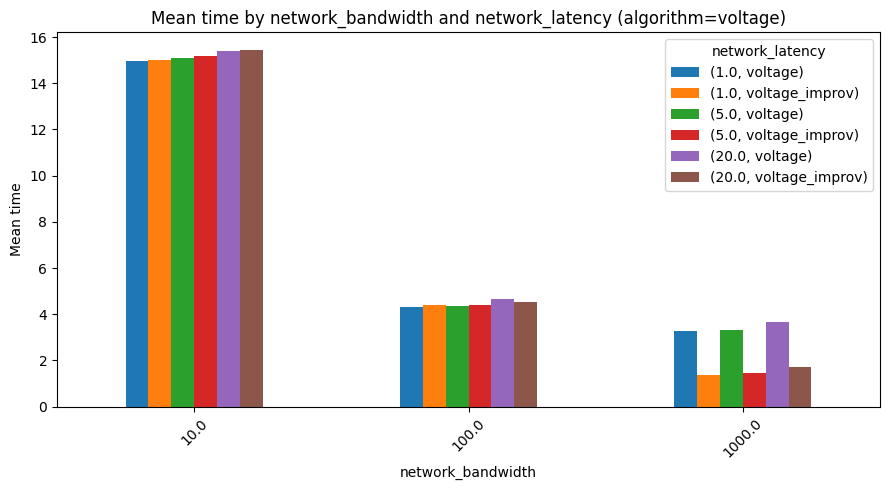

In [71]:
grouped = (
    df.groupby([lat_col, bw_col, alg_col], dropna=False)[time_col]
    .mean()
    .reset_index()
    .rename(columns={time_col: "mean_time"})
    .sort_values([lat_col, bw_col, alg_col])
)

# pivot so each latency becomes a series and bandwidth is on the x axis
pivot = grouped.pivot(index=bw_col, columns=[lat_col, alg_col], values="mean_time")

ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel(bw_col)
ax.set_ylabel(f"Mean {time_col}")
ax.set_title("Mean time by network_bandwidth and network_latency (algorithm=voltage)")
plt.xticks(rotation=45)
plt.legend(title=lat_col)
plt.tight_layout()
plt.show()

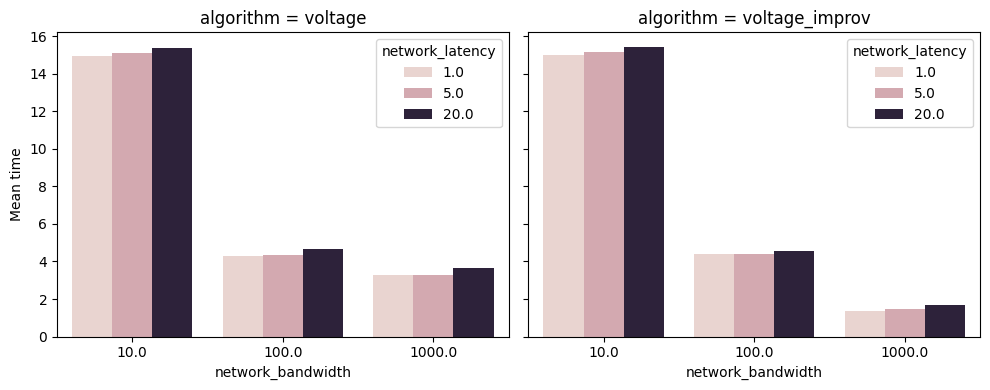

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped2 = (
    df.groupby([lat_col, bw_col, alg_col], dropna=False)[time_col]
      .mean()
      .reset_index()
      .rename(columns={time_col: "mean_time"})
)

algs = grouped2[alg_col].unique()
fig, axes = plt.subplots(1, len(algs), figsize=(5*len(algs), 4), sharey=True)

for ax, alg in zip(axes, algs):
    sub = grouped2[grouped2[alg_col] == alg]
    sns.barplot(
        data=sub,
        x=bw_col,
        y="mean_time",
        hue=lat_col,
        ax=ax
    )
    ax.set_title(f"{alg_col} = {alg}")
    ax.set_xlabel(bw_col)
    ax.set_ylabel("Mean " + time_col)
    ax.legend(title=lat_col)

plt.tight_layout()
plt.show()


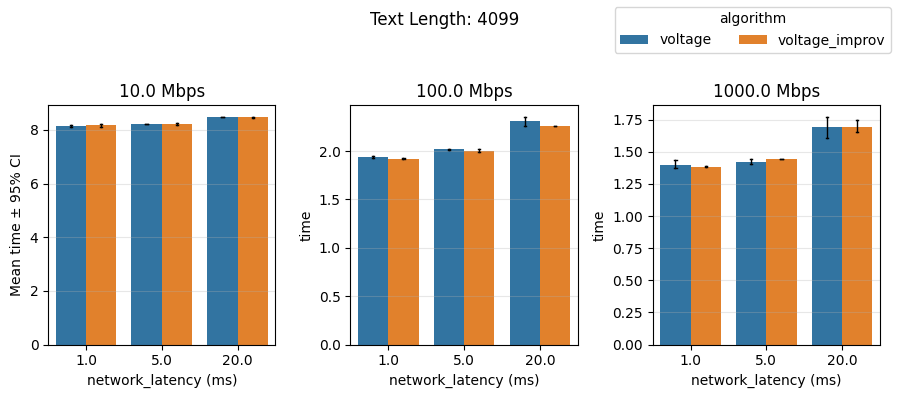

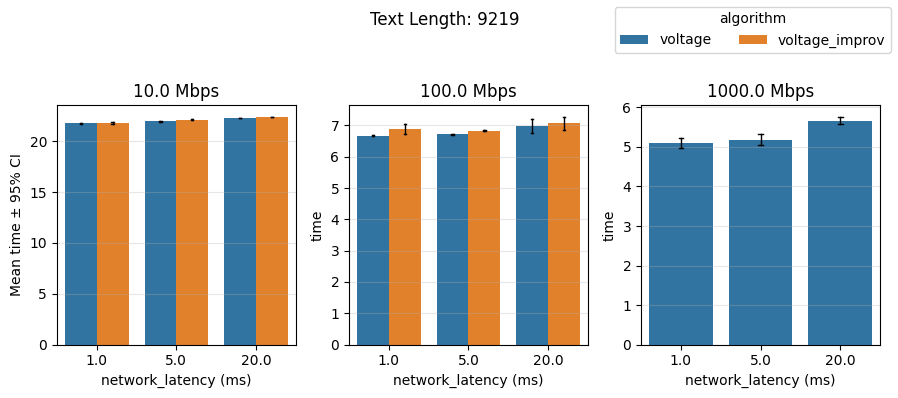

In [73]:
# Use seaborn barplot so we get mean + confidence intervals (default ci=95)
for text_len in df[len_col].unique():
    df_len = df[df[len_col] == text_len]

    # Helpers for ordering
    def _to_num(x):
        try:
            return float(str(x).strip().lower().replace("ms", "").replace("s", ""))
        except:
            return x

    lat_order = sorted(df_len[lat_col].unique(), key=_to_num)
    alg_order = list(df_len[alg_col].dropna().unique())
    bw_vals = sorted(df_len[bw_col].unique(), key=_to_num)

    # determine y-limit from raw data (safer for CI visualization)
    ymax = df_len[time_col].max() * 1.10

    fig, axes = plt.subplots(1, len(bw_vals), figsize=(3 * len(bw_vals), 4), sharey=False)
    if len(bw_vals) == 1:
        axes = [axes]

    for ax, bw in zip(axes, bw_vals):
        sub = df_len[df_len[bw_col] == bw]

        sns.barplot(
            data=sub,
            x=lat_col,
            y=time_col,
            hue=alg_col,
            order=lat_order,
            hue_order=alg_order,
            ax=ax,
            errorbar=('ci', 95),
            capsize=0.06,
            palette="tab10",
            err_kws={'color': 'k', 'linewidth': 1},
        )

        ax.set_title(f"{bw} Mbps")
        ax.set_xlabel(lat_col + " (ms)")
        # ax.set_ylim(0, ymax)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)

    axes[0].set_ylabel(f"Mean {time_col} ± 95% CI")
    fig.suptitle(f"Text Length: {text_len}", fontsize=12)
    # single legend for the figure
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, title=alg_col, loc="upper right", ncol=len(alg_order))
    # remove per-axis legends
    for a in axes:
        a.legend_.remove()
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    # Save as pdf
    plt.savefig(f"../results/voltage_analysis_text_length_{text_len}.pdf")
    plt.show()


In [74]:
from scipy.stats import ttest_ind

results = []

for text_len in df[len_col].unique():
    df_len = df[df[len_col] == text_len]
    for bw in df_len[bw_col].unique():
        for lat in df_len[lat_col].unique():
            sub = df_len[(df_len[lat_col] == lat) & (df_len[bw_col] == bw)]
            vals0 = sub[sub[alg_col] == alg_order[0]][time_col]
            vals1 = sub[sub[alg_col] == alg_order[1]][time_col]
            if len(vals0) > 1 and len(vals1) > 1:
                t_stat, p_val = ttest_ind(vals0, vals1, equal_var=False)
            else:
                p_val = float('nan')
            mean0 = vals0.mean()
            mean1 = vals1.mean()
            if not pd.isna(mean0) and not pd.isna(mean1):
                speedup = mean0 / mean1 if mean1 != 0 else float('nan')
                results.append({
                    len_col: int(text_len),
                    bw_col: int(bw),
                    lat_col: int(lat),
                    f"{alg_order[0]}_mean_time": f"{mean0:.3f}",
                    f"{alg_order[1]}_mean_time": f"{mean1:.3f}",
                    "speedup": f"{(speedup-1)*100:.2f}%",
                    "p_value": f"{p_val:.3f}"
                })

speedup_df = pd.DataFrame(results)
# Export as csv
speedup_df.to_csv("../results/voltage_speedup_analysis.csv", index=False)
display(speedup_df)

,prompt_length,network_bandwidth,network_latency,voltage_mean_time,voltage_improv_mean_time,speedup,p_value
0,4099,10,1,8.146,8.170,-0.29%,0.476
1,4099,10,5,8.218,8.207,0.13%,0.537
2,4099,10,20,8.483,8.462,0.25%,0.000
3,4099,100,1,1.941,1.921,1.04%,0.004
4,4099,100,5,2.019,2.004,0.76%,0.073
5,4099,100,20,2.308,2.257,2.26%,0.087
6,4099,1000,1,1.399,1.384,1.14%,0.354
7,4099,1000,5,1.421,1.443,-1.52%,0.047
8,4099,1000,20,1.688,1.694,-0.33%,0.913
9,9219,10,1,21.763,21.808,-0.21%,0.500
